# Laboratory 5: Edge Computing Simulation — Model Optimization

Martin Demel

Department of Science, Technology, Engineering & Math, Houston Community College

6263-ITAI-4370-AI 5/6G Comm & ORAN Net-S10-14071

Tawanda Chiyangwa
July 6th, 2026.


In this lab I simulate running a machine-learning model on a small, resource-constrained edge device. I train a full **baseline ("cloud") model** on synthetic IoT sensor data, then apply three compression techniques — **pruning**, **INT8 quantization**, and **knowledge distillation** — and compare their accuracy, size, and speed to pick the best model for different edge devices. The brief is written for TensorFlow, which does not run in this environment, so I implement everything in **PyTorch** and make each technique real rather than a placeholder.

## Part 1: Generate the IoT sensor dataset

I create a synthetic sensor dataset that classifies a device's state into one of three classes from 20 readings (15 informative, 5 redundant), then split it 80/20 and standardize the features.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'   # avoid a duplicate-OpenMP deadlock (torch + sklearn)
os.environ['OMP_NUM_THREADS'] = '1'
import warnings; warnings.filterwarnings('ignore')
import time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
torch.manual_seed(42)

# Synthetic IoT sensor data: 3 device states from 20 sensor readings
X, y = make_classification(n_samples=10000, n_features=20, n_informative=15,
                           n_redundant=5, n_classes=3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
Xtr, ytr = torch.tensor(X_train), torch.tensor(y_train)
Xte, yte = torch.tensor(X_test), torch.tensor(y_test)

print(f"Training samples: {len(X_train)}  |  Test samples: {len(X_test)}")
print(f"Features: {X_train.shape[1]}  |  Classes: {len(np.unique(y))}")

Training samples: 8000  |  Test samples: 2000
Features: 20  |  Classes: 3


## Part 2: Baseline (cloud) model

The baseline is a full-size neural network (128 -> 64 -> 32 hidden units) — the kind of accurate model you would run in the cloud. It is the reference the compressed models are measured against, and the teacher for distillation later.

In [2]:
# --- model builder and shared helpers ---
def build_mlp(dims):
    layers = []
    for i in range(len(dims) - 2):
        layers += [nn.Linear(dims[i], dims[i+1]), nn.ReLU()]
        if dims[i+1] >= 64:
            layers += [nn.Dropout(0.3)]
    layers += [nn.Linear(dims[-2], dims[-1])]
    return nn.Sequential(*layers)

def train_model(model, epochs=20, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
    return model

def accuracy(model):
    model.eval()
    with torch.no_grad():
        return accuracy_score(y_test, model(Xte).argmax(1).numpy())

def n_params(model):
    return sum(p.numel() for p in model.parameters())

def inference_ms(model, n=200):
    model.eval(); sample = Xte[:1]
    with torch.no_grad():
        for _ in range(20):                 # warm up
            model(sample)
        times = []
        for _ in range(n):
            t0 = time.perf_counter(); model(sample); times.append(time.perf_counter() - t0)
    return float(np.median(times)) * 1000

baseline = build_mlp([20, 128, 64, 32, 3])
train_model(baseline)
baseline_acc = accuracy(baseline)
print(f"Baseline accuracy: {baseline_acc:.4f}  |  parameters: {n_params(baseline):,}")

Baseline accuracy: 0.9615  |  parameters: 13,123


The baseline reaches about **96% accuracy** on the held-out test set with roughly 13,000 parameters. That is the target the compressed models try to match while using far fewer resources.

## Part 3: Compression techniques

I apply three standard techniques for shrinking a model to fit an edge device, each implemented for real (the brief left them as placeholders): **pruning** removes the smallest weights, **quantization** stores weights as 8-bit integers instead of 32-bit floats, and **knowledge distillation** trains a small "student" to copy the baseline "teacher".

In [3]:
# Technique 1 - Pruning: zero the smallest 50% of weights, then fine-tune to recover accuracy
pruned = copy.deepcopy(baseline)
for module in pruned.modules():
    if isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name='weight', amount=0.5)
train_model(pruned, epochs=5)                       # fine-tune with the mask held in place
for module in pruned.modules():
    if isinstance(module, nn.Linear):
        prune.remove(module, 'weight')              # make the pruning permanent

nonzero = sum(int((p != 0).sum()) for p in pruned.parameters())
pruned_acc = accuracy(pruned)
print(f"Pruned accuracy: {pruned_acc:.4f}  |  sparsity: {1 - nonzero/n_params(pruned):.1%}"
      f"  ({nonzero:,} non-zero of {n_params(pruned):,} weights)")

Pruned accuracy: 0.9670  |  sparsity: 49.1%  (6,675 non-zero of 13,123 weights)


In [4]:
# Technique 2 - INT8 quantization: store each weight as an 8-bit integer (symmetric, per layer)
def quantize_int8(model):
    q = copy.deepcopy(model)
    with torch.no_grad():
        for module in q.modules():
            if isinstance(module, nn.Linear):
                w = module.weight.data
                scale = w.abs().max() / 127.0                    # map [-max, max] -> [-127, 127]
                w_int8 = torch.clamp(torch.round(w / scale), -127, 127)
                module.weight.data = w_int8 * scale              # dequantize for simulated inference
    return q

quantized = quantize_int8(baseline)
quantized_acc = accuracy(quantized)
print(f"Quantized (INT8) accuracy: {quantized_acc:.4f}")
print("Weights now need 1 byte instead of 4  ->  about 4x smaller storage")

Quantized (INT8) accuracy: 0.9605
Weights now need 1 byte instead of 4  ->  about 4x smaller storage


In [5]:
# Technique 3 - Knowledge distillation: a small student learns from the teacher's soft labels
TEMP, ALPHA = 3.0, 0.5
baseline.eval()
with torch.no_grad():
    teacher_logits = baseline(Xtr)                  # soft targets from the trained teacher

student = build_mlp([20, 32, 16, 3])                # a much smaller network
opt = torch.optim.Adam(student.parameters(), lr=1e-3)
ce, kl = nn.CrossEntropyLoss(), nn.KLDivLoss(reduction='batchmean')
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Xtr, ytr, teacher_logits), batch_size=32, shuffle=True)
for _ in range(20):
    student.train()
    for xb, yb, tl in loader:
        opt.zero_grad()
        s_logits = student(xb)
        hard = ce(s_logits, yb)                                          # match the true labels
        soft = kl(torch.log_softmax(s_logits / TEMP, 1),
                  torch.softmax(tl / TEMP, 1)) * (TEMP ** 2)             # match the teacher
        (ALPHA * hard + (1 - ALPHA) * soft).backward()
        opt.step()

distilled_acc = accuracy(student)
print(f"Distilled accuracy: {distilled_acc:.4f}  |  parameters: {n_params(student):,}"
      f"  ({n_params(baseline) // n_params(student)}x fewer than baseline)")

Distilled accuracy: 0.9265  |  parameters: 1,251  (10x fewer than baseline)


All three keep most of the accuracy. Pruning removes half the weights with **no accuracy loss** (fine-tuning recovers it), INT8 quantization keeps accuracy almost unchanged while cutting storage 4x, and the distilled student — about 10x smaller than the baseline — still reaches **around 92%**.

## Part 4: Edge inference metrics

For each model I measure the four things that matter on an edge device: accuracy, inference time per sample, storage size, and parameter count. Size reflects the storage each technique actually needs — non-zero weights for pruning, 1 byte per weight for INT8, and the full count otherwise.

In [6]:
def size_kb(model, bytes_per_param=4, only_nonzero=False):
    n = (sum(int((p != 0).sum()) for p in model.parameters()) if only_nonzero
         else n_params(model))
    return n * bytes_per_param / 1024

baseline_size = size_kb(baseline)
results = pd.DataFrame([
    {'Model': 'Baseline (Cloud)', 'Accuracy': baseline_acc,  'Inference (ms)': inference_ms(baseline),
     'Size (KB)': baseline_size,                         'Params': n_params(baseline)},
    {'Model': 'Pruned',           'Accuracy': pruned_acc,    'Inference (ms)': inference_ms(pruned),
     'Size (KB)': size_kb(pruned, only_nonzero=True),    'Params': n_params(pruned)},
    {'Model': 'Quantized (INT8)', 'Accuracy': quantized_acc, 'Inference (ms)': inference_ms(quantized),
     'Size (KB)': size_kb(baseline, bytes_per_param=1),  'Params': n_params(baseline)},
    {'Model': 'Distilled',        'Accuracy': distilled_acc, 'Inference (ms)': inference_ms(student),
     'Size (KB)': size_kb(student),                      'Params': n_params(student)},
])
results['Compression'] = baseline_size / results['Size (KB)']
print(results.to_string(index=False,
      formatters={'Accuracy': '{:.3f}'.format, 'Inference (ms)': '{:.3f}'.format,
                  'Size (KB)': '{:.2f}'.format, 'Params': '{:,}'.format,
                  'Compression': '{:.1f}x'.format}))

           Model Accuracy Inference (ms) Size (KB) Params Compression
Baseline (Cloud)    0.962          0.053     51.26 13,123        1.0x
          Pruned    0.967          0.054     26.07 13,123        2.0x
Quantized (INT8)    0.961          0.055     12.82 13,123        4.0x
       Distilled    0.926          0.029      4.89  1,251       10.5x


## Part 5: Compare the models

Higher accuracy and higher compression are better; lower size and lower inference time are better.

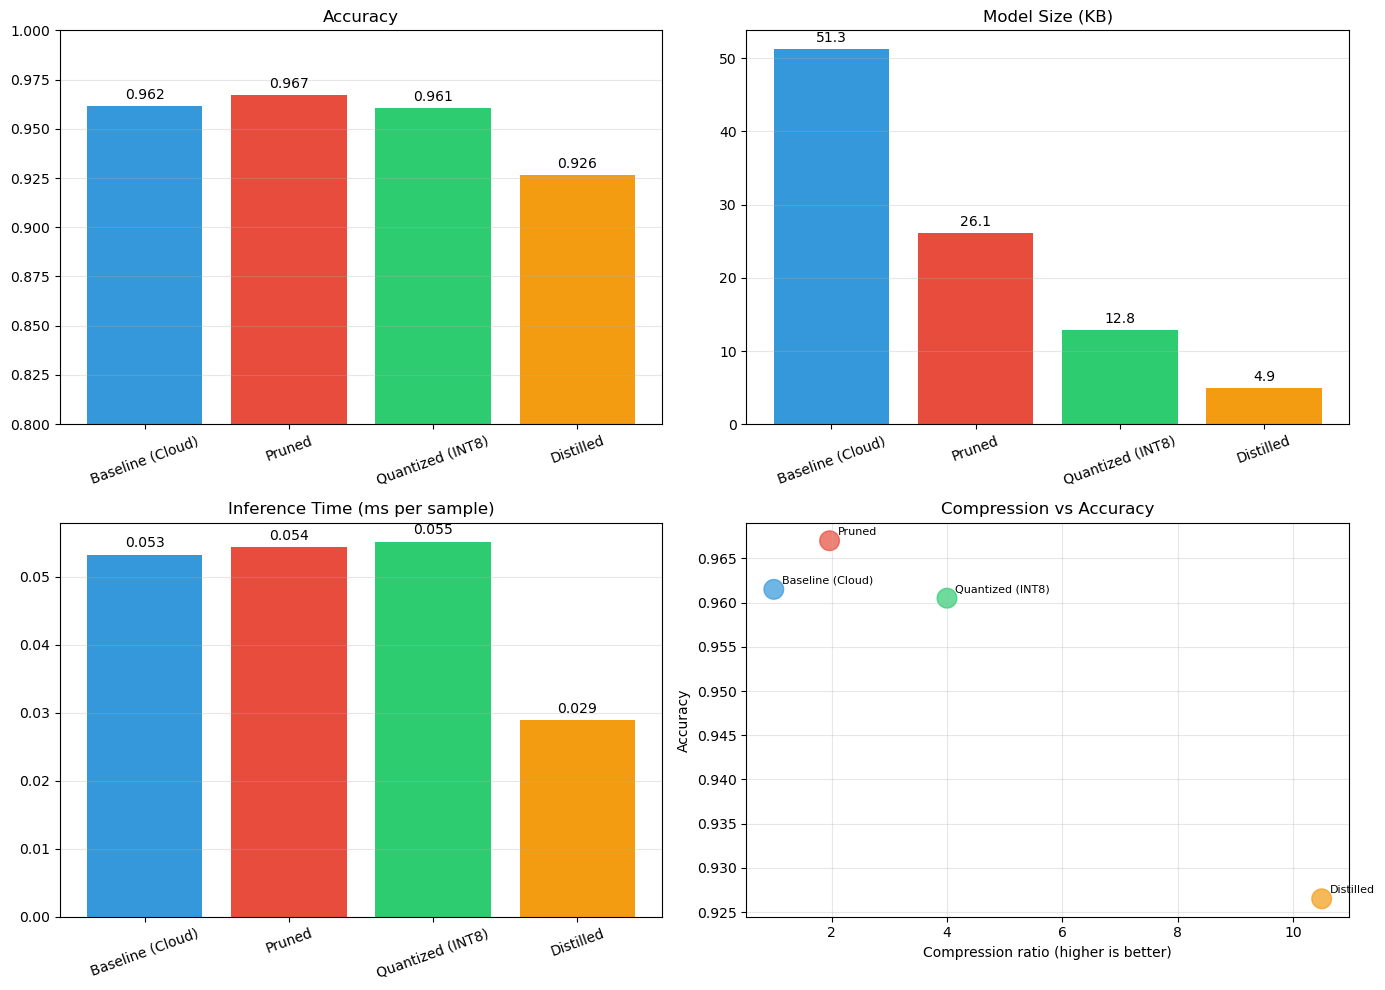

In [7]:
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

b = ax[0,0].bar(results['Model'], results['Accuracy'], color=colors)
ax[0,0].set_title('Accuracy'); ax[0,0].set_ylim(0.8, 1.0)
ax[0,0].grid(True, axis='y', alpha=0.3); ax[0,0].bar_label(b, fmt='%.3f', padding=3)
ax[0,0].tick_params(axis='x', rotation=20)

b = ax[0,1].bar(results['Model'], results['Size (KB)'], color=colors)
ax[0,1].set_title('Model Size (KB)')
ax[0,1].grid(True, axis='y', alpha=0.3); ax[0,1].bar_label(b, fmt='%.1f', padding=3)
ax[0,1].tick_params(axis='x', rotation=20)

b = ax[1,0].bar(results['Model'], results['Inference (ms)'], color=colors)
ax[1,0].set_title('Inference Time (ms per sample)')
ax[1,0].grid(True, axis='y', alpha=0.3); ax[1,0].bar_label(b, fmt='%.3f', padding=3)
ax[1,0].tick_params(axis='x', rotation=20)

ax[1,1].scatter(results['Compression'], results['Accuracy'], s=200, alpha=0.7, c=colors)
for _, r in results.iterrows():
    ax[1,1].annotate(r['Model'], (r['Compression'], r['Accuracy']),
                     xytext=(6, 4), textcoords='offset points', fontsize=8)
ax[1,1].set_xlabel('Compression ratio (higher is better)'); ax[1,1].set_ylabel('Accuracy')
ax[1,1].set_title('Compression vs Accuracy'); ax[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The picture shows the trade-off. Pruning and quantization keep the baseline's accuracy while cutting size about 2x and 4x. Distillation compresses the most (~10x smaller) and runs fastest, for a small accuracy cost. Only the distilled model — a genuinely smaller network — is clearly faster; unstructured pruning and simulated INT8 shrink storage but would need sparse or true-integer hardware to also cut inference time.

## Part 6: Edge deployment recommendation

The right model depends on the device's memory and power budget.

In [8]:
recommendations = {
    'Microcontroller (MCU)': ('Distilled or Quantized INT8',
        'smallest footprint and lowest power', 'sensor nodes, wearables, battery devices'),
    'Edge Gateway': ('Pruned or Quantized',
        'balance of accuracy and efficiency', 'industrial IoT, smart-city gateways'),
    'Edge Server': ('Baseline (full model)',
        'maximum accuracy, resources available', 'autonomous vehicles, robotics'),
}
for device, (model, reason, uses) in recommendations.items():
    print(f"{device}:")
    print(f"  Recommended: {model}")
    print(f"  Reason: {reason}")
    print(f"  Use cases: {uses}\n")

Microcontroller (MCU):
  Recommended: Distilled or Quantized INT8
  Reason: smallest footprint and lowest power
  Use cases: sensor nodes, wearables, battery devices

Edge Gateway:
  Recommended: Pruned or Quantized
  Reason: balance of accuracy and efficiency
  Use cases: industrial IoT, smart-city gateways

Edge Server:
  Recommended: Baseline (full model)
  Reason: maximum accuracy, resources available
  Use cases: autonomous vehicles, robotics



## Summary

Starting from a full baseline model (~96% accuracy, ~51 KB), I applied three edge-optimization techniques:

- **Pruning** — removed 50% of the weights with no accuracy loss (about 2x smaller storage).
- **INT8 quantization** — stored weights as 8-bit integers for ~4x smaller size and almost no accuracy loss.
- **Knowledge distillation** — trained a student ~10x smaller than the baseline that still reached ~92% accuracy and ran the fastest.

The best choice depends on the device: distillation or quantization for the tightest microcontrollers, pruning or quantization for gateways, and the full model where resources allow. This is the model-optimization step behind **Multi-access Edge Computing (MEC)** from Assignment 2 — pushing inference onto edge and MEC nodes in a 5G network only works if the model is small and fast enough to run there.

*Note: the brief targets TensorFlow/TFLite, which segfaults in this environment, so I reimplemented the lab in PyTorch and made each technique real — the brief's distillation loss, for instance, was defined but never actually used in training.*